# Analysis of crypt compositions

In [157]:
# If you edit paths, re-run this cell and everything below.
import os, glob
import numpy as np
import pandas as pd

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get
from organograph.crypts.analysis_markers import *
from organograph.crypts.analysis import field_stats_along_crypt

from organograph.io_utils.segmentation_io import load_graph_crypt_segmentation, load_mesh_crypt_segmentation

# -----------------------
# CONFIG (edit these)
# -----------------------
DATASET      = "20250929" # 20250929 20251201

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

SEG_DIR      = os.path.join(PROJECT_ROOT, "..", "NicoleData", DATASET, "crypt_segmentations_graph_exclusive")
GRAPHS_DIR   = os.path.join(PROJECT_ROOT, "..", "NicoleData", DATASET, "graphs_preprocessed_exclusive")


# Timepoints to consider (None -> auto-discover from GRAPHS_DIR)
TIMEPOINTS = ["day3p5"] #['day3p5', 'day4', 'day4p5', 'day4p5-more'] #["day4p5"]  # or None



#### Utilities

In [158]:
def discover_timepoints(seg_dir):
    if not os.path.isdir(seg_dir):
        return []
    tps = []
    for name in sorted(os.listdir(seg_dir)):
        p = os.path.join(seg_dir, name)
        if os.path.isdir(p) and glob.glob(os.path.join(p, "*.npz")):
            tps.append(name)
    return tps

def _seg_get(seg, *keys, default=None):
    """Return the first existing key from seg."""
    for k in keys:
        if k in seg:
            return seg[k]
    return default


def _safe_array(x):
    if x is None:
        return None
    return np.asarray(x)


def _as_list_of_lists(x):
    """
    Normalize stored crypt list from npz/object-array into a Python list[list[int]].
    """
    if x is None:
        return []
    if isinstance(x, list):
        return [list(xx) for xx in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [list(xx) for xx in x.tolist()]
    return [list(xx) for xx in x]


def _infer_marker_names(G, marker_names=None):
    """
    Try to infer marker names from the graph if not provided.
    """
    if marker_names is not None:
        return list(marker_names)

    # common places where this may live
    for k in ["marker_names", "markers", "marker_cols"]:
        v = G.graph.get(k, None)
        if v is not None:
            return list(v)

    # fall back to shape only
    markers_bin = graph_get(G, "markers_bin")
    n_markers = markers_bin.shape[1]
    return [f"marker_{i}" for i in range(n_markers)]


def _infer_label_uid(G, fallback=None):
    return G.graph.get("label_uid", None) or fallback


In [159]:
# -------------------------------------------------------
# Extract marker names directly from one sample graph
# -------------------------------------------------------

def get_sample_graph_path(seg_dir, timepoints=None):
    """
    Find one segmentation file and return its graph_path.
    """
    if timepoints is None:
        timepoints = discover_timepoints(seg_dir)

    for tp in timepoints:
        tp_dir = os.path.join(seg_dir, tp)
        seg_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
        if len(seg_files) == 0:
            continue

        seg = load_graph_crypt_segmentation(seg_files[0])
        gpath = seg.get("graph_path", None)

        if gpath is not None and os.path.exists(gpath):
            return gpath

    raise RuntimeError("Could not find any valid graph_path in segmentations.")


# --- load one sample graph ---
sample_graph_path = get_sample_graph_path(SEG_DIR, TIMEPOINTS)
print("Sample graph:", sample_graph_path)

G_sample = load_cell_graph(sample_graph_path)

# --- extract marker names from graph ---
MARKER_NAMES = _infer_marker_names(G_sample)

print("MARKER_NAMES from graph =", MARKER_NAMES)


# --- update marker indices ---
def _safe_marker_index(name):
    if name in MARKER_NAMES:
        return MARKER_NAMES.index(name)
    print(f"[warning] marker '{name}' not found in graph markers.")
    return None


i_LGR5  = _safe_marker_index("LGR5")
i_AldoB = _safe_marker_index("AldoB")
i_Sero  = _safe_marker_index("Serotonin")
i_Lyso  = _safe_marker_index("Lysozyme")
# i_KI67 = _safe_marker_index("KI67")

Sample graph: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/graphs_preprocessed_exclusive/day3p5/day3p5_A01_1.gpickle
MARKER_NAMES from graph = ['LGR5', 'Chroma', 'Mucin 2', 'AldoB', 'Glucagon', 'Agr2', 'Serotonin', 'Lysozyme', 'TA']


### Filtering crypts by marker content

In [160]:
from organograph.crypts.filters import filter_crypts_by_markers

crypt_filter = lambda G, crypts_graph, seg: filter_crypts_by_markers(
    G,
    crypts_graph,
    pos_markers=[],
    neg_markers=[i_AldoB],
    pos_min=2,
    neg_min=2,
    roi_frac=0.65,
    dist_bottom=seg["d_crypts_graph"],
    require_all_pos=True,
)

### Inspection table

In [161]:

def build_inspection_table(
    seg_dir,
    timepoints=None,
    verbose=True,
    marker_names=None,
    min_positive=1,
    pos_threshold=1,
    i_LGR5=None,
    i_Sero=None,
    i_Lyso=None,
    crypt_filter=None,
):
    if timepoints is None:
        timepoints = discover_timepoints(seg_dir)

    rows_out = []

    for tp in timepoints:
        tp_dir = os.path.join(seg_dir, tp)
        for seg_path in sorted(glob.glob(os.path.join(tp_dir, "*.npz"))):

            # load segmentation
            try:
                seg = load_graph_crypt_segmentation(seg_path)
            except Exception as e:
                if verbose:
                    print(f"[skip] could not load segmentation {seg_path}: {e}")
                continue

            # load graph
            try:
                G = load_cell_graph(seg["graph_path"])
            except Exception as e:
                if verbose:
                    print(f"[skip] could not load graph {seg.get('graph_path', None)}: {e}")
                continue

            crypts_graph = _as_list_of_lists(
                _seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])
            )
            constrictions = _safe_array(_seg_get(seg, "crypt_constrictions", default=None))
            elongations = _safe_array(_seg_get(seg, "crypt_elongations", "crypt_elongationss", default=None))
            graph_patch_sizes = _safe_array(_seg_get(seg, "graph_patch_sizes", default=None))

            label_uid = _seg_get(seg, "label_uid", default=None)
            label_uid = _infer_label_uid(G, fallback=label_uid)

            cur_marker_names = _infer_marker_names(G, marker_names=marker_names)
            n_markers = len(cur_marker_names)

            n_crypts = len(crypts_graph)

            # ---------------------------
            # run filter once
            # ---------------------------
            if crypt_filter is None:
                keep_idx = np.arange(n_crypts, dtype=np.int64)
            else:
                keep = crypt_filter(G, crypts_graph, seg)

                if isinstance(keep, np.ndarray) and keep.dtype == bool:
                    if len(keep) != n_crypts:
                        raise ValueError(
                            f"crypt_filter returned boolean mask of length {len(keep)}, "
                            f"expected {n_crypts}"
                        )
                    keep_idx = np.flatnonzero(keep)

                else:
                    keep_idx = np.asarray(keep, dtype=np.int64)

            # optional sanity checks
            if keep_idx.ndim != 1:
                raise ValueError("keep_idx must be a 1D array of crypt indices")
            if len(keep_idx) > 0:
                if keep_idx.min() < 0 or keep_idx.max() >= n_crypts:
                    raise ValueError("crypt_filter returned out-of-range crypt indices")

            # ---------------------------
            # subset all aligned per-crypt data
            # ---------------------------
            crypts_graph_f = [crypts_graph[j] for j in keep_idx]
            constrictions_f = constrictions[keep_idx] if constrictions is not None else None
            elongations_f = elongations[keep_idx] if elongations is not None else None
            graph_patch_sizes_f = graph_patch_sizes[keep_idx] if graph_patch_sizes is not None else None

            # keep original crypt ids for traceability
            orig_crypt_numbers_f = keep_idx

            # ---------------------------
            # iterate over filtered crypts
            # ---------------------------
            for local_idx, crypt_cells in enumerate(crypts_graph_f):

                crypt_cells = list(crypt_cells)
                if len(crypt_cells) == 0:
                    continue

                orig_j = int(orig_crypt_numbers_f[local_idx])

                num_pos_cells, num_cells = get_marker_counts_per_patch(G, crypt_cells)
                num_pos_cells = np.asarray(num_pos_cells, dtype=np.int64)

                if num_pos_cells.shape[0] != n_markers:
                    raise ValueError(
                        f"Marker count mismatch for {seg_path}: "
                        f"counts have length {num_pos_cells.shape[0]}, "
                        f"marker_names has length {n_markers}"
                    )

                has_marker = (num_pos_cells >= min_positive).astype(np.int64)

                if None not in (i_LGR5, i_Sero, i_Lyso):
                    cat = assign_coexpression_category(
                        G,
                        crypt_cells,
                        i_LGR5,
                        i_Sero,
                        i_Lyso,
                        pos_threshold=pos_threshold,
                    )
                else:
                    cat = np.nan

                constr = (
                    float(constrictions_f[local_idx])
                    if constrictions_f is not None and local_idx < len(constrictions_f)
                    else np.nan
                )

                row = {
                    "timepoint": tp,
                    "label_uid": label_uid,
                    "crypt_number": orig_j,              # original index in segmentation
                    "crypt_number_filtered": local_idx,  # index within filtered subset
                    "graph_path": seg.get("graph_path", None),
                    "mesh_path": seg.get("mesh_path", None),
                    "seg_path": seg_path if os.path.exists(seg_path) else None,
                    "has_seg": bool(os.path.exists(seg_path)),
                    "num_cells": int(num_cells),
                    "constriction": constr,
                    "elongation": (
                        float(elongations_f[local_idx])
                        if elongations_f is not None and local_idx < len(elongations_f)
                        else np.nan
                    ),
                    "graph_patch_size": (
                        int(graph_patch_sizes_f[local_idx])
                        if graph_patch_sizes_f is not None and local_idx < len(graph_patch_sizes_f)
                        else int(num_cells)
                    ),
                    "coexpression_cat": cat,
                    "is_budded": (constr > 0) if not np.isnan(constr) else np.nan,
                }

                for k, mk in enumerate(cur_marker_names):
                    row[f"{mk}_n_pos"] = int(num_pos_cells[k])
                    row[f"{mk}_frac_pos"] = float(num_pos_cells[k] / num_cells) if num_cells > 0 else np.nan
                    row[f"{mk}_has"] = int(has_marker[k])

                rows_out.append(row)

    df = pd.DataFrame(rows_out)

    if len(df) == 0:
        return df

    has_cols = [c for c in df.columns if c.endswith("_has")]
    df["n_markers_present"] = df[has_cols].sum(axis=1)

    return df

In [162]:
inspection_df = build_inspection_table(
    seg_dir=SEG_DIR,
    min_positive=1,
    pos_threshold=1,
    i_LGR5=i_LGR5,
    i_Sero=i_Sero,
    i_Lyso=i_Lyso,
    crypt_filter=crypt_filter,
)

inspection_df.head()

,timepoint,label_uid,crypt_number,crypt_number_filtered,graph_path,mesh_path,seg_path,has_seg,num_cells,constriction,...,Serotonin_n_pos,Serotonin_frac_pos,Serotonin_has,Lysozyme_n_pos,Lysozyme_frac_pos,Lysozyme_has,TA_n_pos,TA_frac_pos,TA_has,n_markers_present
0,day3p5,day3p5_A01_12,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,14,0.0,...,0,0.000000,0,2,0.142857,1,4,0.285714,1,5
1,day3p5,day3p5_A01_12,1,1,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,16,0.0,...,0,0.000000,0,2,0.125000,1,11,0.687500,1,3
2,day3p5,day3p5_A01_13,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,50,0.0,...,2,0.040000,1,5,0.100000,1,0,0.000000,0,5
3,day3p5,day3p5_A01_16,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,53,0.0,...,1,0.018868,1,9,0.169811,1,25,0.471698,1,6
4,day3p5,day3p5_A01_16,1,1,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,32,0.0,...,1,0.031250,1,0,0.000000,0,21,0.656250,1,3


### Plot crypt composition

In [163]:
import matplotlib.pyplot as plt

def plot_fraction_of_crypts_with_marker(
    inspection_df,
    marker_names=None,
    constriction_col="constriction",
    figsize=(10, 5),
    normalize_within_group=True,
):
    """
    For each marker, plot the fraction of crypts where that marker is present.
    Bars are stacked into:
      - bulged: constriction == 0
      - budded: constriction > 0

    If normalize_within_group=True:
        bulged height  = (# bulged crypts with marker) / (total # crypts)
        budded height  = (# budded crypts with marker) / (total # crypts)
        total bar      = overall fraction of crypts with marker

    If normalize_within_group=False:
        same result here in practice because both parts are fractions of all crypts.
        I kept the flag only for future flexibility.
    """
    df = inspection_df.copy()

    if marker_names is None:
        marker_names = [c[:-4] for c in df.columns if c.endswith("_has")]

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    budded = df[constriction_col] > 0
    bulged = df[constriction_col] == 0
    n_total = len(df)

    bulged_vals = []
    budded_vals = []

    for mk in marker_names:
        col = f"{mk}_has"
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")

        bulged_vals.append(df.loc[bulged, col].sum() / n_total)
        budded_vals.append(df.loc[budded, col].sum() / n_total)

    x = np.arange(len(marker_names))

    plt.figure(figsize=figsize)
    plt.bar(x, bulged_vals, label="bulged (constriction = 0)")
    plt.bar(x, budded_vals, bottom=bulged_vals, label="budded (constriction > 0)")
    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylabel("fraction of crypts")
    plt.title("Fraction of crypts with marker present")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_fraction_of_cells_positive_by_marker(
    inspection_df,
    marker_names=None,
    constriction_col="constriction",
    num_cells_col="num_cells",
    figsize=(10, 5),
):
    """
    For each marker, plot the fraction of cells positive for that marker.

    Two bars per marker:
        - bulged crypts (constriction == 0)
        - budded crypts (constriction > 0)

    Fractions are normalized within each category:
        bulged fraction = positive cells in bulged crypts / total cells in bulged crypts
        budded fraction = positive cells in budded crypts / total cells in budded crypts
    """

    df = inspection_df.copy()

    if marker_names is None:
        marker_names = [c[:-6] for c in df.columns if c.endswith("_n_pos")]

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    bulged = df[constriction_col] == 0
    budded = df[constriction_col] > 0

    total_cells_bulged = df.loc[bulged, num_cells_col].sum()
    total_cells_budded = df.loc[budded, num_cells_col].sum()

    if total_cells_bulged == 0 or total_cells_budded == 0:
        raise ValueError("One category contains zero cells")

    bulged_vals = []
    budded_vals = []

    for mk in marker_names:

        npos_col = f"{mk}_n_pos"

        if npos_col not in df.columns:
            raise KeyError(f"Missing column: {npos_col}")

        bulged_vals.append(
            df.loc[bulged, npos_col].sum() / total_cells_bulged
        )

        budded_vals.append(
            df.loc[budded, npos_col].sum() / total_cells_budded
        )

    x = np.arange(len(marker_names))
    width = 0.38

    plt.figure(figsize=figsize)

    plt.bar(
        x - width / 2,
        bulged_vals,
        width,
        label="bulged (constriction = 0)",
    )

    plt.bar(
        x + width / 2,
        budded_vals,
        width,
        label="budded (constriction > 0)",
    )

    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylabel("fraction of cells")
    plt.title("Fraction of cells positive for each marker")
    plt.legend()

    plt.tight_layout()
    plt.show()

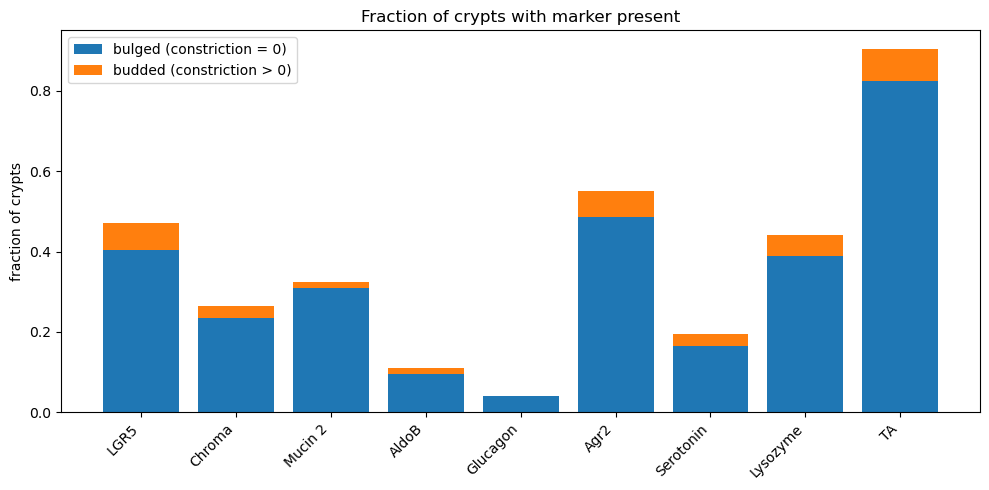

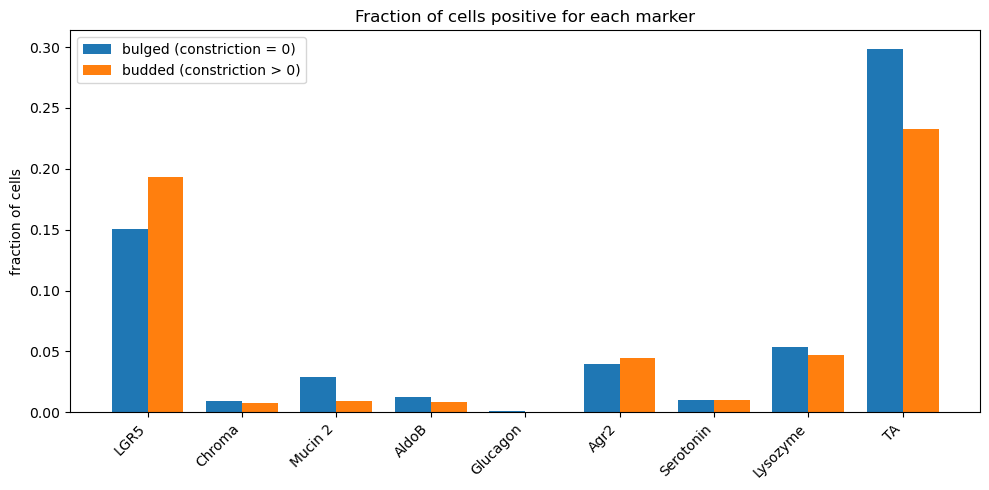

In [164]:
# df_sel = inspection_df.query("timepoint == 'day3p5'").copy() # restrict to subset

plot_fraction_of_crypts_with_marker(inspection_df)
plot_fraction_of_cells_positive_by_marker(inspection_df)

In [165]:
def _resolve_marker_names_from_table(df, mode="has"):
    if mode == "has":
        return [c[:-4] for c in df.columns if c.endswith("_has")]
    elif mode == "n_pos":
        return [c[:-6] for c in df.columns if c.endswith("_n_pos")]
    else:
        raise ValueError(f"Unknown mode: {mode}")


def _resolve_timepoint_order(df, timepoint_col="timepoint", timepoint_order=None):
    if timepoint_order is not None:
        return list(timepoint_order)
    return list(df[timepoint_col].dropna().unique())


def plot_fraction_of_crypts_with_marker_over_time(
    inspection_df,
    marker_names=None,
    timepoint_col="timepoint",
    constriction_col="constriction",
    timepoint_order=None,
    ncols=2,
    fig_width=7,
    row_height=2.6,
):
    """
    For each marker, plot the fraction of crypts where that marker is present
    as a function of timepoint.

    Each subplot contains two curves:
      - bulged: constriction == 0
      - budded: constriction > 0

    Fractions are normalized within each morphology class at each timepoint:
      bulged fraction = (# bulged crypts with marker) / (# bulged crypts)
      budded fraction = (# budded crypts with marker) / (# budded crypts)
    """
    df = inspection_df.copy()

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    if marker_names is None:
        marker_names = _resolve_marker_names_from_table(df, mode="has")
    marker_names = list(marker_names)

    timepoints = _resolve_timepoint_order(df, timepoint_col=timepoint_col, timepoint_order=timepoint_order)
    x = np.arange(len(timepoints))

    n_markers = len(marker_names)
    nrows = int(np.ceil(n_markers / ncols))
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mk in zip(axes, marker_names):
        col = f"{mk}_has"
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")

        bulged_vals = []
        budded_vals = []

        for tp in timepoints:
            df_tp = df[df[timepoint_col] == tp]

            bulged = df_tp[constriction_col] == 0
            budded = df_tp[constriction_col] > 0

            n_bulged = bulged.sum()
            n_budded = budded.sum()

            bulged_vals.append(
                df_tp.loc[bulged, col].mean() if n_bulged > 0 else np.nan
            )
            budded_vals.append(
                df_tp.loc[budded, col].mean() if n_budded > 0 else np.nan
            )

        ax.plot(x, bulged_vals, marker="o", linewidth=2, label="bulged")
        ax.plot(x, budded_vals, marker="o", linewidth=2, label="budded")

        ax.set_title(mk, fontweight="bold")
        ax.set_ylabel("fraction of crypts")
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel("timepoint")
            ax.set_xticks(x)
            ax.set_xticklabels(timepoints, rotation=45, ha="right")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()


def plot_fraction_of_cells_positive_by_marker_over_time(
    inspection_df,
    marker_names=None,
    timepoint_col="timepoint",
    constriction_col="constriction",
    num_cells_col="num_cells",
    timepoint_order=None,
    ncols=2,
    fig_width=7,
    row_height=2.6,
):
    """
    For each marker, plot the fraction of cells positive for that marker
    as a function of timepoint.

    Each subplot contains two curves:
      - bulged: constriction == 0
      - budded: constriction > 0

    Fractions are normalized within each morphology class at each timepoint:
      bulged fraction = (positive cells in bulged crypts) / (total cells in bulged crypts)
      budded fraction = (positive cells in budded crypts) / (total cells in budded crypts)
    """
    df = inspection_df.copy()

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    if marker_names is None:
        marker_names = _resolve_marker_names_from_table(df, mode="n_pos")
    marker_names = list(marker_names)

    timepoints = _resolve_timepoint_order(df, timepoint_col=timepoint_col, timepoint_order=timepoint_order)
    x = np.arange(len(timepoints))

    n_markers = len(marker_names)
    nrows = int(np.ceil(n_markers / ncols))
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mk in zip(axes, marker_names):
        npos_col = f"{mk}_n_pos"
        if npos_col not in df.columns:
            raise KeyError(f"Missing column: {npos_col}")

        bulged_vals = []
        budded_vals = []

        for tp in timepoints:
            df_tp = df[df[timepoint_col] == tp]

            bulged = df_tp[constriction_col] == 0
            budded = df_tp[constriction_col] > 0

            total_cells_bulged = df_tp.loc[bulged, num_cells_col].sum()
            total_cells_budded = df_tp.loc[budded, num_cells_col].sum()

            bulged_vals.append(
                df_tp.loc[bulged, npos_col].sum() / total_cells_bulged
                if total_cells_bulged > 0 else np.nan
            )
            budded_vals.append(
                df_tp.loc[budded, npos_col].sum() / total_cells_budded
                if total_cells_budded > 0 else np.nan
            )

        ax.plot(x, bulged_vals, marker="o", linewidth=2, label="bulged")
        ax.plot(x, budded_vals, marker="o", linewidth=2, label="budded")

        ax.set_title(mk, fontweight="bold")
        ax.set_ylabel("fraction of cells")
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel("timepoint")
            ax.set_xticks(x)
            ax.set_xticklabels(timepoints, rotation=45, ha="right")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()

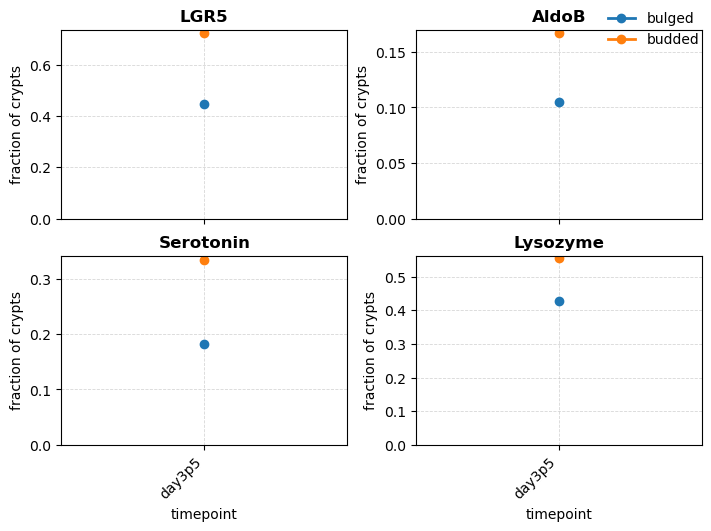

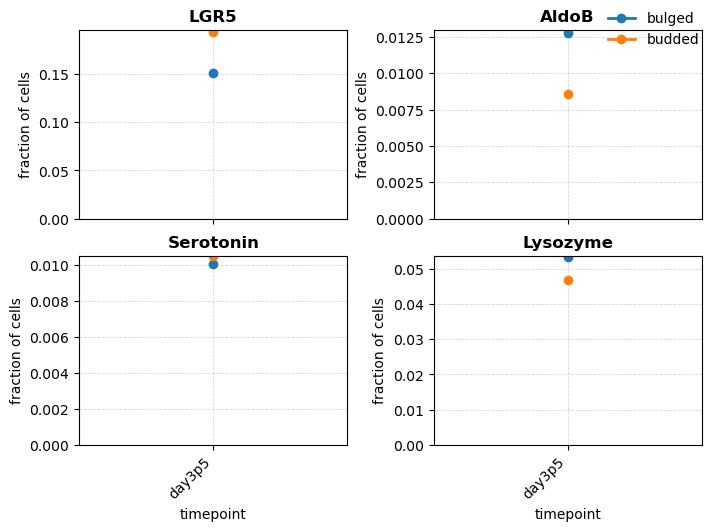

In [166]:
plot_fraction_of_crypts_with_marker_over_time(
    inspection_df,
    marker_names=["LGR5", "AldoB", "Serotonin", "Lysozyme"],
)

plot_fraction_of_cells_positive_by_marker_over_time(
    inspection_df,
    marker_names=["LGR5", "AldoB", "Serotonin", "Lysozyme"],
)

### Plot co-expression

In [167]:
import numpy as np
import matplotlib.pyplot as plt


def expected_coexpression_fractions_within_LGR5_subgroups(
    df_group,
    marker_names,
    i_LGR5,
    i_Sero,
    i_Lyso,
):
    """
    Compute expected coexpression fractions under independence within the
    LGR5+ and LGR5- subgroups separately.

    Returns
    -------
    exp : (8,) array
        Categories 0..3 are conditional within LGR5+ crypts:
          0 = S+ Y-
          1 = Y+ S-
          2 = S- Y-
          3 = S+ Y+

        Categories 4..7 are conditional within LGR5- crypts:
          4 = S+ Y-
          5 = Y+ S-
          6 = S- Y-
          7 = S+ Y+
    """
    col_L = f"{marker_names[i_LGR5]}_has"
    col_S = f"{marker_names[i_Sero]}_has"
    col_Y = f"{marker_names[i_Lyso]}_has"

    exp = np.full(8, np.nan, dtype=float)

    df_pos = df_group[df_group[col_L] == 1]
    df_neg = df_group[df_group[col_L] == 0]

    if len(df_pos) > 0:
        pS_pos = df_pos[col_S].mean()
        pY_pos = df_pos[col_Y].mean()

        exp[0] = pS_pos * (1.0 - pY_pos)          # S+ Y-
        exp[1] = pY_pos * (1.0 - pS_pos)          # Y+ S-
        exp[2] = (1.0 - pS_pos) * (1.0 - pY_pos)  # S- Y-
        exp[3] = pS_pos * pY_pos                  # S+ Y+

    if len(df_neg) > 0:
        pS_neg = df_neg[col_S].mean()
        pY_neg = df_neg[col_Y].mean()

        exp[4] = pS_neg * (1.0 - pY_neg)          # S+ Y-
        exp[5] = pY_neg * (1.0 - pS_neg)          # Y+ S-
        exp[6] = (1.0 - pS_neg) * (1.0 - pY_neg)  # S- Y-
        exp[7] = pS_neg * pY_neg                  # S+ Y+

    return exp


def plot_grouped_bars_with_expected(
    observed,
    expected,
    xtick_labels,
    title,
    group_names,
    figsize=(6, 5),
    dpi=150,
):
    """
    observed: (n_groups, 8)
    expected: (n_groups, 8)

    Two panels:
      - top: categories 0..3, shown as fraction of LGR5+ crypts
      - bottom: categories 4..7, shown as fraction of LGR5- crypts
    """
    observed = np.asarray(observed, float)
    expected = np.asarray(expected, float)

    if observed.shape != expected.shape:
        raise ValueError("observed and expected must have same shape")

    n_groups, K = observed.shape
    if K != 8:
        raise ValueError(f"Expected 8 categories, got {K}")

    idx_pos = np.arange(0, 4)
    idx_neg = np.arange(4, 8)

    w = min(0.22, 0.8 / max(n_groups, 1))
    offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * w

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        dpi=dpi,
        constrained_layout=True,
        sharey=True,
    )

    def _panel(ax, idxs, ylabel, show_legend=False):
        x = np.arange(4)

        for gi in range(n_groups):
            ax.bar(
                x + offsets[gi],
                observed[gi, idxs],
                width=0.8 * w,
                edgecolor="white",
                linewidth=0.7,
                alpha=0.9,
                label=group_names[gi] if show_legend else None,
                zorder=2,
            )

        for gi in range(n_groups):
            ax.bar(
                x + offsets[gi],
                expected[gi, idxs],
                width=0.8 * w,
                facecolor="none",
                edgecolor="black",
                linewidth=1.3,
                linestyle="--",
                label="Expected (indep.)" if (show_legend and gi == 0) else None,
                zorder=3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=25, ha="right")
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_ylim(bottom=0)

    _panel(axes[0], idx_pos, ylabel="Fraction of LGR5+ crypts", show_legend=True)
    _panel(axes[1], idx_neg, ylabel="Fraction of LGR5- crypts", show_legend=False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, ncol=min(3, len(labels)), loc="upper right")

    fig.suptitle(title, y=1.02, fontsize=13)
    plt.show()


def aggregate_composition_from_table(df_group, marker_names, i_LGR5, i_Sero, i_Lyso):
    """
    Aggregate one selected group of crypts from inspection_df.

    Returns
    -------
    fp : (M,) marker presence fractions across all crypts in the group
    fcat : (8,) coexpression category fractions, conditional within LGR5+ or LGR5-
           fcat[0:4] sums to 1 over LGR5+ crypts
           fcat[4:8] sums to 1 over LGR5- crypts
    n : int
        Number of crypts in the group
    """
    n = len(df_group)

    if n == 0:
        fp = np.full(len(marker_names), np.nan, dtype=float)
        fcat = np.full(8, np.nan, dtype=float)
        return fp, fcat, 0

    has_cols = [f"{m}_has" for m in marker_names]
    fp = df_group[has_cols].mean(axis=0).to_numpy(dtype=float)

    cat = df_group["coexpression_cat"].to_numpy()
    valid = np.isfinite(cat)
    cat = cat[valid].astype(int)

    fcat = np.full(8, np.nan, dtype=float)

    if len(cat) > 0:
        counts = np.bincount(cat, minlength=8).astype(float)

        n_pos = counts[:4].sum()
        n_neg = counts[4:].sum()

        if n_pos > 0:
            fcat[:4] = counts[:4] / n_pos
        if n_neg > 0:
            fcat[4:] = counts[4:] / n_neg

    return fp, fcat, n


def plot_coexpression_from_inspection_table(
    inspection_df,
    marker_names,
    group_specs,
    labels_cond=None,
    title="",
):
    """
    Parameters
    ----------
    inspection_df : pd.DataFrame
    marker_names : list[str]
    group_specs : list of (group_name, selector)
        selector can be:
          - boolean mask aligned with inspection_df
          - callable: selector(df) -> boolean mask
    labels_cond : list[str] or None
        Labels for the 4 subcategories within each LGR5 sign block.
    """
    i_LGR5 = marker_names.index("LGR5")
    i_Sero = marker_names.index("Serotonin")
    i_Lyso = marker_names.index("Lysozyme")

    if labels_cond is None:
        labels_cond = ["S+ Y-", "Y+ S-", "S- Y-", "S+ Y+"]

    group_names = []
    frac_categories_obs = []
    frac_categories_exp = []
    Ns = []
    Ns_pos = []
    Ns_neg = []

    for group_name, selector in group_specs:
        if callable(selector):
            mask = np.asarray(selector(inspection_df), dtype=bool)
        else:
            mask = np.asarray(selector, dtype=bool)

        df_group = inspection_df.loc[mask].copy()

        _, fcat, n = aggregate_composition_from_table(
            df_group=df_group,
            marker_names=marker_names,
            i_LGR5=i_LGR5,
            i_Sero=i_Sero,
            i_Lyso=i_Lyso,
        )

        fexp = expected_coexpression_fractions_within_LGR5_subgroups(
            df_group=df_group,
            marker_names=marker_names,
            i_LGR5=i_LGR5,
            i_Sero=i_Sero,
            i_Lyso=i_Lyso,
        )

        cat = df_group["coexpression_cat"].to_numpy()
        valid = np.isfinite(cat)
        cat = cat[valid].astype(int)
        counts = np.bincount(cat, minlength=8).astype(int) if len(cat) > 0 else np.zeros(8, dtype=int)

        group_names.append(group_name)
        frac_categories_obs.append(fcat)
        frac_categories_exp.append(fexp)
        Ns.append(int(n))
        Ns_pos.append(int(counts[:4].sum()))
        Ns_neg.append(int(counts[4:].sum()))

    frac_categories_obs = np.vstack(frac_categories_obs)
    frac_categories_exp = np.vstack(frac_categories_exp)

    plot_grouped_bars_with_expected(
        observed=frac_categories_obs,
        expected=frac_categories_exp,
        xtick_labels=labels_cond,
        title=title,
        group_names=group_names,
    )

    print("N crypts per plotted group:", dict(zip(group_names, Ns)))
    print("N LGR5+ crypts per plotted group:", dict(zip(group_names, Ns_pos)))
    print("N LGR5- crypts per plotted group:", dict(zip(group_names, Ns_neg)))

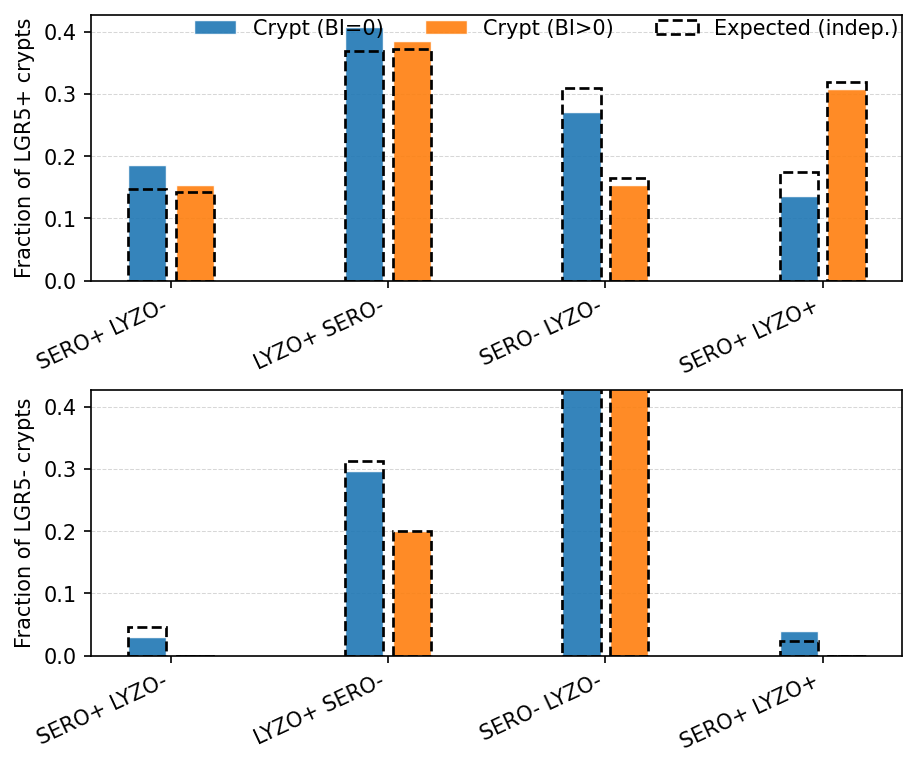

N crypts per plotted group: {'Crypt (BI=0)': 182, 'Crypt (BI>0)': 18}
N LGR5+ crypts per plotted group: {'Crypt (BI=0)': 81, 'Crypt (BI>0)': 13}
N LGR5- crypts per plotted group: {'Crypt (BI=0)': 101, 'Crypt (BI>0)': 5}


In [168]:
group_specs = [
    ("Crypt (BI=0)", lambda df: df["constriction"].to_numpy() == 0),
    ("Crypt (BI>0)", lambda df: df["constriction"].to_numpy() > 0),
]

# df_sel = inspection_df.query("timepoint == 'D3'").copy() # restrict to subset


plot_coexpression_from_inspection_table(
    inspection_df=inspection_df,
    marker_names=MARKER_NAMES,
    group_specs=group_specs,
    labels_cond=["SERO+ LYZO-", "LYZO+ SERO-", "SERO- LYZO-", "SERO+ LYZO+"],
    title="",
)

### Plot marker distribution along crypt axis

In [169]:
def collect_binned_marker_profiles_from_table(
    inspection_df,
    bin_edges,
    marker_names=None,
    marker_subset=None,
    seg_path_col="seg_path",
    crypt_number_col="crypt_number",
    markers_key="markers_bin",
    crypts_key_candidates=("crypts_graph", "crypts_ll", "graph_crypts_ll"),
    distance_key="d_crypts_graph",
):
    """
    Collect per-crypt binned marker positivity profiles for the crypts selected
    in inspection_df.

    Uses:
        markers = markers_bin[crypt_cells]
        distance = seg[distance_key][crypt_idx]

    Returns
    -------
    dict with keys:
        "bin_edges"
        "bin_centers"
        "marker_names"
        "marker_subset"
        "marker_indices"
        "marker_pos_counts"   : list of (Msel, B)
        "marker_cell_counts"  : list of (B,)
        "meta"                : dataframe aligned to the lists above
    """
    bin_edges = np.asarray(bin_edges, dtype=float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    df = inspection_df.dropna(subset=[seg_path_col, crypt_number_col]).copy()
    df[crypt_number_col] = df[crypt_number_col].astype(int)

    marker_pos_counts_all = []
    marker_cell_counts_all = []
    meta_rows = []

    resolved_marker_names = None
    resolved_marker_subset = None
    marker_indices = None

    for seg_path, df_seg in df.groupby(seg_path_col, sort=False):
        seg = load_graph_crypt_segmentation(seg_path)
        G = load_cell_graph(seg["graph_path"])

        crypts_graph = _as_list_of_lists(
            _seg_get(seg, *crypts_key_candidates, default=[])
        )
        d_crypts_graph = seg[distance_key]
        markers_bin = np.asarray(graph_get(G, markers_key))

        if resolved_marker_names is None:
            resolved_marker_names = _infer_marker_names(G, marker_names=marker_names)

            if marker_subset is None:
                resolved_marker_subset = list(resolved_marker_names)
            else:
                resolved_marker_subset = list(marker_subset)

            marker_indices = [resolved_marker_names.index(m) for m in resolved_marker_subset]

        for _, row in df_seg.iterrows():
            crypt_idx = int(row[crypt_number_col])
            crypt_cells = np.asarray(list(crypts_graph[crypt_idx]), dtype=np.int64)

            counts_pos, counts_tot = bin_marker_positivity(
                markers_bin[:, marker_indices],
                distance=seg[distance_key][crypt_idx],
                bin_edges=bin_edges,
            )

            marker_pos_counts_all.append(counts_pos)
            marker_cell_counts_all.append(counts_tot)
            meta_rows.append(row.to_dict())

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "marker_names": resolved_marker_names,
        "marker_subset": resolved_marker_subset,
        "marker_indices": marker_indices,
        "marker_pos_counts": marker_pos_counts_all,
        "marker_cell_counts": marker_cell_counts_all,
        "meta": pd.DataFrame(meta_rows).reset_index(drop=True),
    }

In [170]:
def lighten_color(rgb_or_hex, amount=0.55):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def mean_and_sem(frac_group):
    mu = np.nanmean(frac_group, axis=0)
    sd = np.nanstd(frac_group, axis=0, ddof=1)
    n = np.sum(np.isfinite(frac_group), axis=0)
    se = sd / np.sqrt(np.maximum(n, 1))
    return mu, se


def plot_binned_marker_profiles(
    binned_data,
    target_markers=None,
    group_masks=None,
    group_labels=None,
    group_colors=None,
    row_height=2.3,
    fig_width=6,
    ncols=2,
    ylabel="fraction of cells",
    xlabel=r"$d$ (normalized distance; neck at 1)",
):

    marker_subset = list(binned_data["marker_subset"])
    bin_centers = np.asarray(binned_data["bin_centers"])
    meta = binned_data["meta"]

    pos_flat = np.stack(binned_data["marker_pos_counts"], axis=0).astype(float)
    tot_flat = np.stack(binned_data["marker_cell_counts"], axis=0).astype(float)
    frac_flat = pos_flat / np.maximum(tot_flat[:, None, :], 1.0)

    if target_markers is None:
        target_markers = marker_subset
    target_markers = list(target_markers)
    target_indices = [marker_subset.index(m) for m in target_markers]

    if group_masks is None:
        group_masks = [np.ones(len(meta), dtype=bool)]
        group_labels = ["all"]
        group_colors = ["#1f77b4"]

    default_palette = {
        "LGR5": "#1f77b4",
        "AldoB": "#2ca02c",
        "Serotonin": "#d62728",
        "Lysozyme": "#9467bd",
    }

    n_markers = len(target_markers)
    nrows = int(np.ceil(n_markers / ncols))

    # 👇 dynamic figure height
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=False,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, m_idx, marker_name in zip(axes, target_indices, target_markers):

        base = default_palette.get(marker_name, "#1f77b4")
        colors_this = [base, lighten_color(base, 0.55)] if len(group_masks) == 2 else group_colors

        for gmask, glabel, gcolor in zip(group_masks, group_labels, colors_this):

            mu, se = mean_and_sem(frac_flat[gmask, m_idx, :])

            ax.fill_between(bin_centers, mu - se, mu + se, color=gcolor, alpha=0.20, linewidth=0)
            ax.plot(bin_centers, mu, color=gcolor, linewidth=2.0,
                    label=f"{glabel} (N={int(np.sum(gmask))})")

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=0)

        ax.text(
            0.02, 0.98,
            marker_name,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel(xlabel)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()

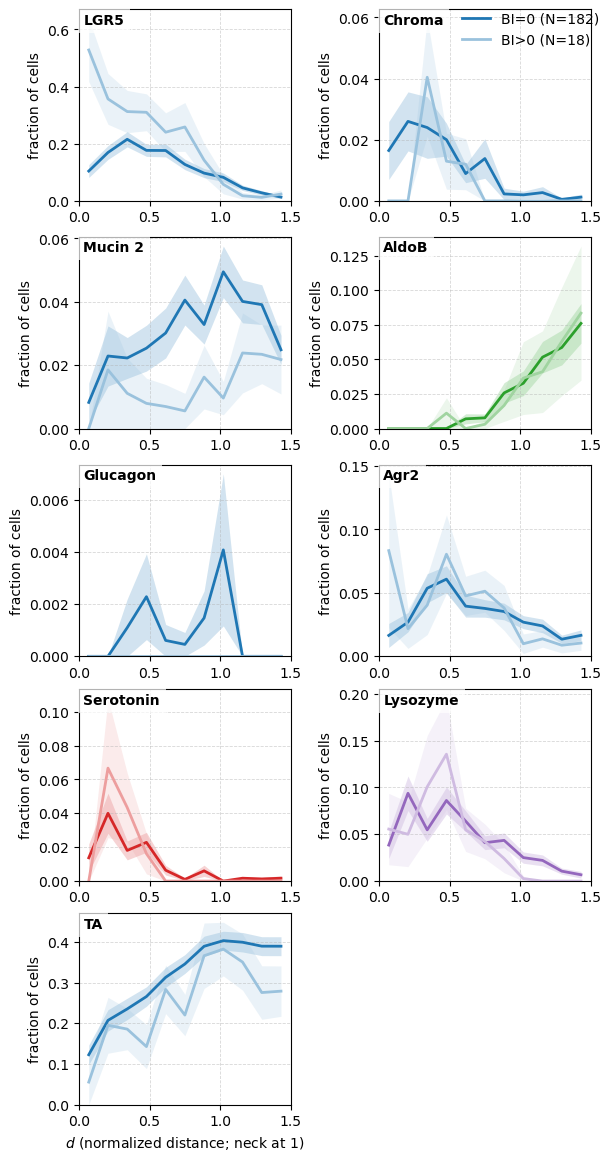

In [171]:
target_markers = None # ["LGR5", "AldoB", "Serotonin", "Lysozyme"]

bin_edges = np.linspace(0, 1.5, 12)

binned = collect_binned_marker_profiles_from_table(
    inspection_df=inspection_df,
    bin_edges=bin_edges,
    marker_names=MARKER_NAMES,
    marker_subset=target_markers,
)

meta = binned["meta"]
m_bulged = meta["constriction"].to_numpy() == 0
m_budded = meta["constriction"].to_numpy() > 0

plot_binned_marker_profiles(
    binned_data=binned,
    target_markers=target_markers,
    group_masks=[m_bulged, m_budded],
    group_labels=["BI=0", "BI>0"],
    group_colors=["#1f77b4", "#1f77b4"],
    ncols=2,
)

### Plot crypt elongations

In [172]:
import numpy as np
import matplotlib.pyplot as plt


def _get_default_coexpression_category_names():
    return {
        0: "LGR5+ / Sero+ / Lyso-",
        1: "LGR5+ / Sero- / Lyso+",
        2: "LGR5+ / Sero- / Lyso-",
        3: "LGR5+ / Sero+ / Lyso+",
        4: "LGR5- / Sero+ / Lyso-",
        5: "LGR5- / Sero- / Lyso+",
        6: "LGR5- / Sero- / Lyso-",
        7: "LGR5- / Sero+ / Lyso+",
    }


def plot_histograms_by_coexpression_and_budding(
    inspection_df,
    value_col,
    *,
    coexpression_col="coexpression_cat",
    budded_col="is_budded",
    timepoint_col="timepoint",
    timepoint=None,
    bins=20,
    max_value=None,
    figsize=(13, 6.5),
    category_names=None,
    xlabel=None,
    ylabel="count",
    title=None,
    alpha=0.55,
):
    """
    Plot 2x4 histograms for a quantity, split into bulged and budded within
    each co-expression category.

    Parameters
    ----------
    inspection_df : pd.DataFrame
        Table containing the quantity to plot plus co-expression and budding labels.
    value_col : str
        Column to histogram, e.g. "elongation" or "num_cells".
    coexpression_col : str
        Column containing co-expression category indices 0..7.
    budded_col : str
        Boolean column; True = budded, False = bulged.
    timepoint_col : str
        Timepoint column.
    timepoint : str or None
        Optional timepoint filter.
    bins : int or array-like
        Histogram bins.
    max_value : float or None
        If not None, all values >= max_value are pooled into the final bin.
    figsize : tuple
        Figure size.
    category_names : dict or None
        Mapping category index -> display name.
    xlabel : str or None
        X-axis label. If None, uses value_col.
    ylabel : str
        Y-axis label.
    title : str or None
        Optional figure title.
    alpha : float
        Histogram transparency.
    """
    df = inspection_df.copy()

    if timepoint is not None:
        df = df[df[timepoint_col] == timepoint]

    if category_names is None:
        category_names = _get_default_coexpression_category_names()

    vals_all = df[value_col].to_numpy(dtype=float)
    vals_all = vals_all[np.isfinite(vals_all)]
    if vals_all.size == 0:
        raise ValueError(f"No finite values found in column '{value_col}'.")

    if max_value is None:
        if np.isscalar(bins):
            bin_edges = np.histogram_bin_edges(vals_all, bins=int(bins))
        else:
            bin_edges = np.asarray(bins, float)
    else:
        if np.isscalar(bins):
            # int(bins) bins means int(bins)-1 regular bins plus final clipped edge
            bin_edges = np.linspace(np.nanmin(vals_all), max_value, int(bins))
        else:
            bin_edges = np.asarray(bins, float)

    fig, axes = plt.subplots(2, 4, figsize=figsize, sharex=True, sharey=False, constrained_layout=True)
    axes = axes.ravel()

    ymax = 0

    for cat in range(8):
        ax = axes[cat]
        df_cat = df[df[coexpression_col] == cat]

        for is_budded, label in [(False, "bulged"), (True, "budded")]:
            vals = df_cat.loc[df_cat[budded_col] == is_budded, value_col].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]

            if vals.size == 0:
                continue

            vals_plot = vals.copy()
            if max_value is not None:
                vals_plot[vals_plot >= max_value] = max_value

            counts, _, _ = ax.hist(
                vals_plot,
                bins=bin_edges,
                alpha=alpha,
                label=f"{label} (N={vals.size})",
            )
            ymax = max(ymax, np.max(counts))

            ax.axvline(np.mean(vals_plot), linestyle="--", linewidth=1.5)

        if max_value is not None:
            ax.axvline(max_value, linestyle=":", linewidth=1.2, color="red")

        ax.set_title(category_names.get(cat, f"cat {cat}"), fontweight="bold", fontsize=10)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylim(bottom=0)
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    if xlabel is None:
        xlabel = value_col

    for ax in axes[4:]:
        ax.set_xlabel(xlabel)
    for ax in axes[::4]:
        ax.set_ylabel(ylabel)

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.show()



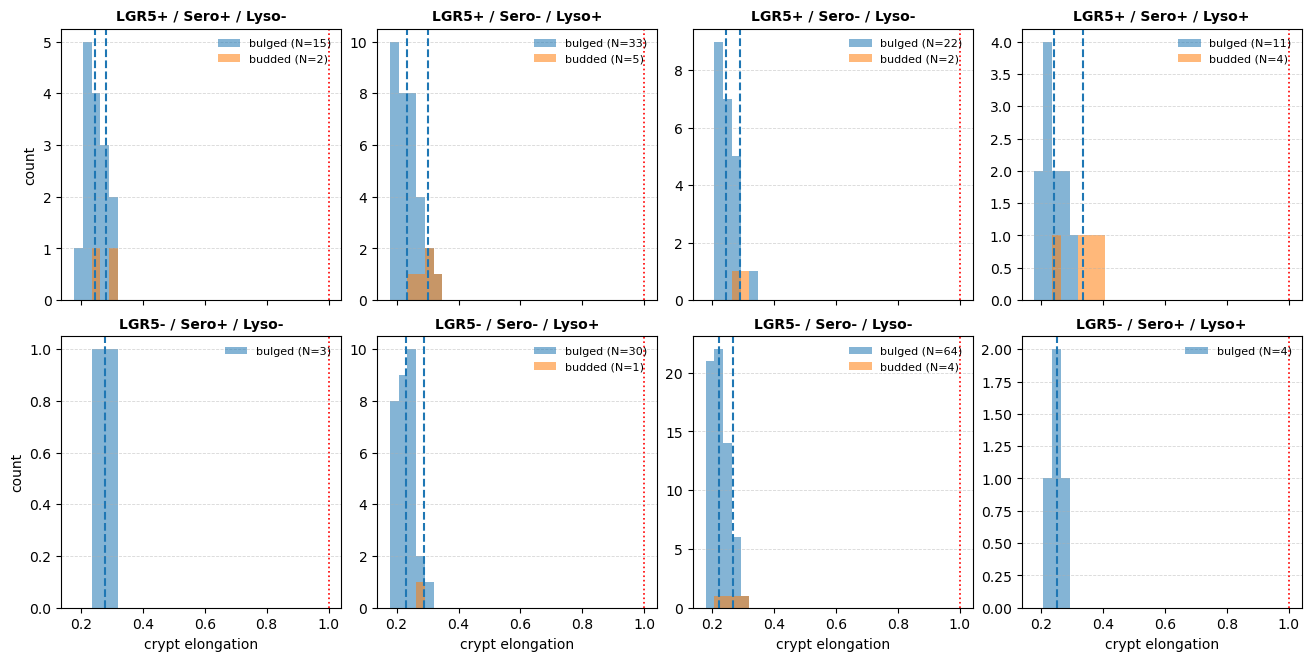

In [173]:
plot_histograms_by_coexpression_and_budding(
    inspection_df,
    value_col="elongation",
    # timepoint='day4',
    bins=30,
    max_value=1.0,
    xlabel="crypt elongation",
)

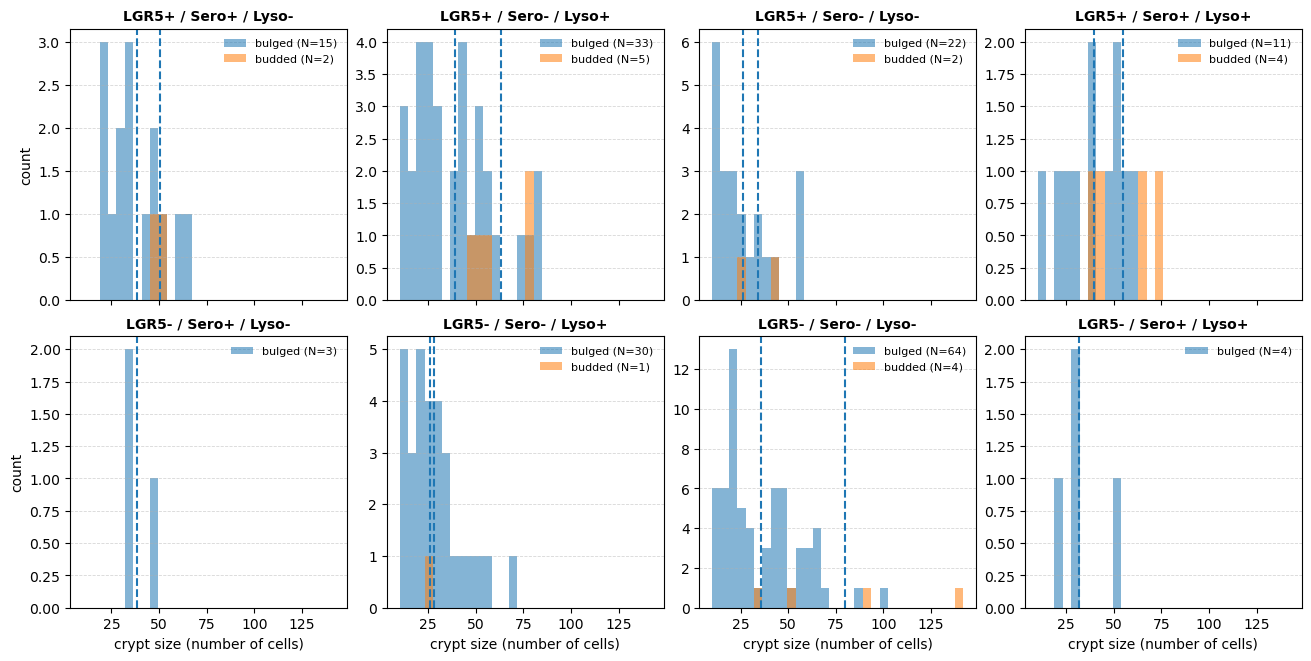

In [174]:
plot_histograms_by_coexpression_and_budding(
    inspection_df,
    value_col="num_cells",
    # timepoint='day4',
    bins=30,
    # max_value=400,
    xlabel="crypt size (number of cells)",
)

### Only serotonin

In [175]:

def add_serotonin_group_from_coexpression(
    inspection_df,
    coexpression_col="coexpression_cat",
    out_col="serotonin_group",
):
    """
    Add a two-level grouping column inferred from co-expression category:
      - 'Serotonin+'
      - 'Serotonin-'
    """
    df = inspection_df.copy()

    sero_pos = {0, 3, 4, 7}
    sero_neg = {1, 2, 5, 6}

    def _map_cat(cat):
        if pd.isna(cat):
            return np.nan
        cat = int(cat)
        if cat in sero_pos:
            return "Serotonin+"
        if cat in sero_neg:
            return "Serotonin-"
        return np.nan

    df[out_col] = df[coexpression_col].map(_map_cat)
    return df


def plot_histograms_by_group(
    inspection_df,
    value_col,
    *,
    group_col,
    group_order=None,
    timepoint_col="timepoint",
    timepoint=None,
    bins=20,
    max_value=None,
    figsize=(8, 3.5),
    xlabel=None,
    ylabel="count",
    title=None,
    alpha=0.7,
    ncols=2,
):
    """
    Plot histograms for a quantity split by a general grouping column.

    Parameters
    ----------
    inspection_df : pd.DataFrame
    value_col : str
        Column to histogram.
    group_col : str
        Grouping column, e.g. 'serotonin_group'.
    group_order : list or None
        Explicit order of groups.
    timepoint : str or None
        Optional timepoint filter.
    bins : int or array-like
        Histogram bins.
    max_value : float or None
        If not None, all values >= max_value are pooled into the final bin.
    ncols : int
        Number of subplot columns.
    """
    df = inspection_df.copy()

    if timepoint is not None:
        df = df[df[timepoint_col] == timepoint]

    vals_all = df[value_col].to_numpy(dtype=float)
    vals_all = vals_all[np.isfinite(vals_all)]

    if vals_all.size == 0:
        raise ValueError(f"No finite values found in column '{value_col}'.")

    if max_value is None:
        if np.isscalar(bins):
            bin_edges = np.histogram_bin_edges(vals_all, bins=int(bins))
        else:
            bin_edges = np.asarray(bins, float)
    else:
        if np.isscalar(bins):
            bin_edges = np.linspace(np.nanmin(vals_all), max_value, int(bins))
        else:
            bin_edges = np.asarray(bins, float)

    if group_order is None:
        groups = list(df[group_col].dropna().unique())
    else:
        groups = list(group_order)

    n_groups = len(groups)
    nrows = int(np.ceil(n_groups / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize if nrows == 1 else (figsize[0], figsize[1] * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    ymax = 0

    for ax, grp in zip(axes, groups):
        vals = df.loc[df[group_col] == grp, value_col].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            vals_plot = vals.copy()
            if max_value is not None:
                vals_plot[vals_plot >= max_value] = max_value

            counts, _, _ = ax.hist(vals_plot, bins=bin_edges, alpha=alpha)
            ymax = max(ymax, np.max(counts))

            ax.axvline(np.mean(vals_plot), linestyle="--", linewidth=1.5, color="k")
            title_here = f"{grp}\nN={vals.size}"
        else:
            title_here = f"{grp}\nN=0"

        if max_value is not None:
            ax.axvline(max_value, linestyle=":", linewidth=1.2, color="red")

        ax.set_title(title_here, fontweight="bold", fontsize=10)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylim(bottom=0)

    for ax in axes[n_groups:]:
        ax.axis("off")

    if ymax > 0:
        for ax in axes[:n_groups]:
            ax.set_ylim(0, ymax * 1.05)

    if xlabel is None:
        xlabel = value_col

    for ax in axes[max(0, n_groups - ncols):n_groups]:
        ax.set_xlabel(xlabel)

    for ax in axes[::ncols]:
        if ax.has_data():
            ax.set_ylabel(ylabel)

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.show()

In [176]:
inspection_df_sero = add_serotonin_group_from_coexpression(
    inspection_df,
    coexpression_col="coexpression_cat",
    out_col="serotonin_group",
)

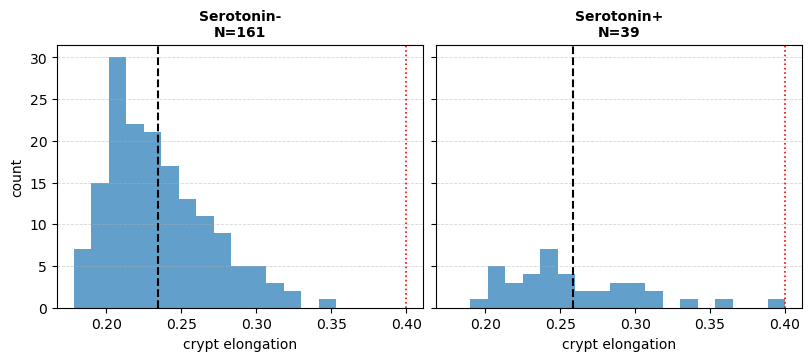

In [177]:
plot_histograms_by_group(
    inspection_df_sero,
    value_col="elongation",
    group_col="serotonin_group",
    group_order=["Serotonin-", "Serotonin+"],
    bins=20,
    max_value=0.4,
    xlabel="crypt elongation",
)

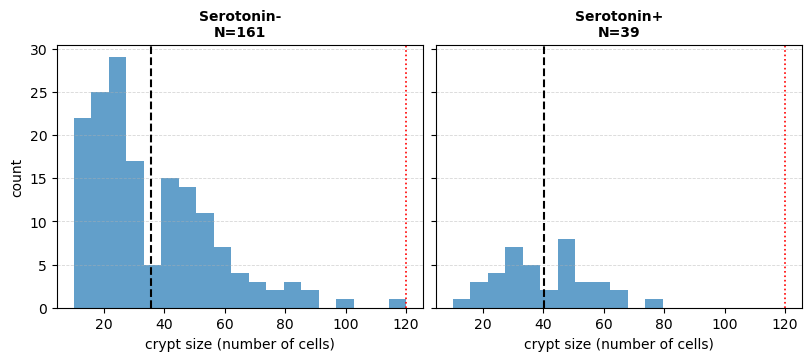

In [178]:
plot_histograms_by_group(
    inspection_df_sero,
    value_col="num_cells",
    group_col="serotonin_group",
    group_order=["Serotonin-", "Serotonin+"],
    bins=20,
    max_value=120,
    xlabel="crypt size (number of cells)",
)

### Curvature analysis

In [179]:

def invert_mesh_to_graph_index(mesh_to_graph_index):
    """
    Convert saved mesh->graph mapping into graph->mesh mapping.

    Parameters
    ----------
    mesh_to_graph_index : (N_mesh_crypts,) array
        For each original mesh crypt, gives filtered graph crypt index or -1.

    Returns
    -------
    graph_to_mesh : dict[int, int]
        Maps filtered graph crypt index -> original mesh crypt index.
    """
    arr = np.asarray(mesh_to_graph_index, dtype=np.int64)
    valid = np.flatnonzero(arr >= 0)
    out = {}
    for mesh_idx in valid:
        gidx = int(arr[mesh_idx])
        out[gidx] = int(mesh_idx)
    return out


def collect_curvature_profiles_from_inspection_table(
    inspection_df,
    bin_edges,
    curvature_key="curvature",
    graph_seg_path_col="seg_path",
    graph_crypt_idx_col="crypt_number",
    mesh_seg_path_key="mesh_seg_path",
    mesh_to_graph_index_key="mesh_to_graph_index",
    d_crypts_key="d_crypts",
    weights_getter=None,
):
    """
    Collect per-crypt curvature-vs-distance profiles for the crypts listed in
    the inspection table.

    Parameters
    ----------
    inspection_df : pd.DataFrame
        Output of build_inspection_table or a filtered subset of it.
        Must contain:
          - seg_path       : path to graph segmentation
          - crypt_number   : graph crypt index within that graph segmentation
    bin_edges : (B+1,) array
        Shared bin edges for s.
    curvature_key : str
        Key of the vertex-wise curvature field in the mesh segmentation.
    weights_getter : callable or None
        Optional function:
            weights = weights_getter(mesh_seg)
        returning per-vertex weights, e.g. vertex areas.
        If None, unweighted stats are used.

    Returns
    -------
    prof_df : pd.DataFrame
        One row per crypt, with metadata from inspection_df plus:
          - mean_profile : (B,) ndarray
          - std_profile  : (B,) ndarray
          - count_profile: (B,) ndarray
          - mesh_crypt_number : original mesh crypt index
    """
    rows_out = []
    bin_edges = np.asarray(bin_edges, float)

    for graph_seg_path, df_seg in inspection_df.groupby(graph_seg_path_col, sort=False):
        graph_seg = load_graph_crypt_segmentation(graph_seg_path)
        mesh_seg_path = graph_seg[mesh_seg_path_key]
        mesh_seg = load_mesh_crypt_segmentation(mesh_seg_path)

        mesh_to_graph_index = np.asarray(graph_seg[mesh_to_graph_index_key], dtype=np.int64)
        graph_to_mesh = invert_mesh_to_graph_index(mesh_to_graph_index)

        curvature = np.asarray(mesh_seg[curvature_key], float)
        d_crypts = mesh_seg[d_crypts_key]

        weights = None if weights_getter is None else np.asarray(weights_getter(mesh_seg), float)

        for _, row in df_seg.iterrows():
            gidx = int(row[graph_crypt_idx_col])
            if gidx not in graph_to_mesh:
                continue

            mesh_idx = graph_to_mesh[gidx]
            s_vertices = np.asarray(d_crypts[mesh_idx], float)

            mean_prof, std_prof, count_prof = field_stats_along_crypt(
                mesh_field=curvature,
                s_vertices=s_vertices,
                bin_edges=bin_edges,
                weights=weights,
            )

            rec = row.to_dict()
            rec["mesh_crypt_number"] = mesh_idx
            rec["mean_profile"] = mean_prof
            rec["std_profile"] = std_prof
            rec["count_profile"] = count_prof
            rec["bin_edges"] = bin_edges
            rows_out.append(rec)

    return pd.DataFrame(rows_out)

In [180]:
def add_curvature_cv_profile(
    prof_df,
    mean_col="mean_profile",
    std_col="std_profile",
    count_col="count_profile",
    out_col="cv_profile",
    rms_min=1e-6,
    min_count=10,
):
    """
    Add per-crypt variability profile

        S = std / RMS_curvature

    computed binwise for each crypt, where RMS_curvature is estimated over the
    entire crypt from the binned mean/std/count profiles.

    For each crypt, the RMS curvature is computed as

        RMS = sqrt( sum_b n_b * (std_b^2 + mean_b^2) / sum_b n_b )

    which corresponds to the vertexwise root-mean-square curvature, approximated
    from the per-bin summary statistics.

    Bins are set to NaN when:
      - too few vertices contributed to that bin
      - the whole-crypt RMS curvature is too small

    Parameters
    ----------
    prof_df : pd.DataFrame
        Must contain columns mean_col, std_col, and count_col, each storing (B,) arrays.
    mean_col : str
        Column containing per-crypt mean profiles.
    std_col : str
        Column containing per-crypt std profiles.
    count_col : str
        Column containing per-crypt vertex counts per bin.
    out_col : str
        Name of output column.
    rms_min : float
        Minimum whole-crypt RMS curvature required to compute the ratio.
    min_count : int
        Minimum number of vertices required in a bin.

    Returns
    -------
    prof_df_out : pd.DataFrame
        Copy of prof_df with added columns:
          - out_col : per-crypt std / RMS profile
          - curvature_rms : whole-crypt RMS curvature
    """
    df = prof_df.copy()

    cv_profiles = []
    rms_vals = []

    bin_edges = np.asarray(df["bin_edges"].iloc[0], float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    rms_mask = bin_centers < 1.0
    
    for mu, sd, cnt in zip(df[mean_col], df[std_col], df[count_col]):
        mu = np.asarray(mu, float)
        sd = np.asarray(sd, float)
        cnt = np.asarray(cnt, float)

        valid_global = np.isfinite(mu) & np.isfinite(sd) & np.isfinite(cnt) & (cnt > 0) & rms_mask

        if not np.any(valid_global):
            rms = np.nan
            s = np.full_like(mu, np.nan, dtype=float)
            cv_profiles.append(s)
            rms_vals.append(rms)
            continue

        # E[K^2] in each bin = Var(K) + E[K]^2 = std^2 + mean^2
        second_moment = sd[valid_global] ** 2 + mu[valid_global] ** 2
        weights = cnt[valid_global]

        rms = np.sqrt(np.sum(weights * second_moment) / np.sum(weights))
        rms_vals.append(rms)

        s = np.full_like(mu, np.nan, dtype=float)
        valid_bin = np.isfinite(mu) & np.isfinite(sd) & (cnt >= min_count) & np.isfinite(rms) & (rms >= rms_min)
        s[valid_bin] = sd[valid_bin] / rms

        cv_profiles.append(s)

    df[out_col] = cv_profiles
    df["curvature_rms"] = rms_vals
    return df



def aggregate_profiles(
    prof_df,
    profile_col="mean_profile",
    group_cols=("coexpression_cat", "is_budded"),
):
    """
    Aggregate per-crypt profiles by group.

    Returns
    -------
    agg_df : pd.DataFrame
        Columns:
          group_cols...
          n
          profile_mean
          profile_sem
    """
    rows = []

    for keys, df_g in prof_df.groupby(list(group_cols), dropna=False, sort=False):
        arr = np.stack(df_g[profile_col].to_list(), axis=0).astype(float)

        mu = np.nanmean(arr, axis=0)
        sd = np.nanstd(arr, axis=0, ddof=1)
        n = np.sum(np.isfinite(arr), axis=0)
        se = sd / np.sqrt(np.maximum(n, 1))

        if not isinstance(keys, tuple):
            keys = (keys,)

        rec = {col: val for col, val in zip(group_cols, keys)}
        rec["n_crypts"] = len(df_g)
        rec["profile_mean"] = mu
        rec["profile_sem"] = se
        rows.append(rec)

    return pd.DataFrame(rows)

In [181]:
def plot_cv_profiles_by_coexpression(
    prof_df,
    profile_col="cv_profile",
    coexpression_col="coexpression_cat",
    budded_col="is_budded",
    timepoint_col="timepoint",
    timepoint=None,
    figsize=(13, 6.5),
    category_names=None,
):
    """
    Plot mean(std / |mean|) along the crypt for each co-expression category.

    Layout:
      - 2x4 subplots for categories 0..7
      - one subplot per co-expression category
      - solid line = mean of S across crypts
      - shaded band = std of S across crypts
      - one curve for bulged and one for budded

    The y-limits are chosen from the mean curves only, not from the shaded area.
    """
    df = prof_df.copy()

    if timepoint is not None:
        df = df[df[timepoint_col] == timepoint]

    bin_edges = np.asarray(df["bin_edges"].iloc[0], float)
    x = 0.5 * (np.asarray(bin_edges[:-1], float) + np.asarray(bin_edges[1:], float))

    if category_names is None:
        category_names = {
            0: "LGR5+ / Sero+ / Lyso-",
            1: "LGR5+ / Sero- / Lyso+",
            2: "LGR5+ / Sero- / Lyso-",
            3: "LGR5+ / Sero+ / Lyso+",
            4: "LGR5- / Sero+ / Lyso-",
            5: "LGR5- / Sero- / Lyso+",
            6: "LGR5- / Sero- / Lyso-",
            7: "LGR5- / Sero+ / Lyso+",
        }

    fig, axes = plt.subplots(2, 4, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()

    global_means = []

    for cat in range(8):
        ax = axes[cat]
        df_cat = df[df[coexpression_col] == cat]

        for is_budded, label, ls in [
            (False, "bulged", "--"),
            (True, "budded", "-"),
        ]:
            df_sub = df_cat[df_cat[budded_col] == is_budded]
            if len(df_sub) == 0:
                continue

            arr = np.stack(df_sub[profile_col].to_list(), axis=0).astype(float)

            mu = np.nanmean(arr, axis=0)
            sd = np.nanstd(arr, axis=0, ddof=1)

            global_means.append(mu)

            ax.fill_between(x, mu - sd, mu + sd, alpha=0.18)
            ax.plot(x, mu, linestyle=ls, linewidth=2, label=f"{label} (N={len(df_sub)})")

        ax.set_title(category_names.get(cat, f"cat {cat}"), fontweight="bold", fontsize=10)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    # y-limits from mean curves only
    if len(global_means) > 0:
        y = np.concatenate([m[np.isfinite(m)] for m in global_means if np.any(np.isfinite(m))])
        if y.size > 0:
            ymin = min(0.0, float(np.nanmin(y)))
            ymax = float(np.nanmax(y))
            if ymin == ymax:
                ymax = ymin + 1.0
            pad = 0.05 * (ymax - ymin)
            for ax in axes:
                ax.set_ylim(ymin - pad, ymax + pad)

    for ax in axes[4:]:
        ax.set_xlabel("distance along crypt")
    for ax in axes[::4]:
        ax.set_ylabel(r"$\mathrm{std} / |\mathrm{mean}|$")

    if timepoint is not None:
        fig.suptitle(f"Curvature variability along crypt — {timepoint}", y=1.02)

    plt.show()


def plot_mean_curvature_profiles_by_coexpression(
    prof_df,
    mean_col="mean_profile",
    std_col="std_profile",
    coexpression_col="coexpression_cat",
    budded_col="is_budded",
    timepoint_col="timepoint",
    timepoint=None,
    figsize=(13, 6.5),
    category_names=None,
):
    """
    Plot mean curvature along the crypt for each co-expression category.

    Layout:
      - 2x4 subplots for categories 0..7
      - one subplot per co-expression category
      - solid line = mean of per-crypt mean-curvature profiles across crypts
      - shaded band = std of per-crypt mean-curvature profiles across crypts

    The y-limits are chosen from the mean curves only, not from the shaded area.
    """
    df = prof_df.copy()

    if timepoint is not None:
        df = df[df[timepoint_col] == timepoint]

    bin_edges = np.asarray(df["bin_edges"].iloc[0], float)
    x = 0.5 * (np.asarray(bin_edges[:-1], float) + np.asarray(bin_edges[1:], float))

    if category_names is None:
        category_names = {
            0: "LGR5+ / Sero+ / Lyso-",
            1: "LGR5+ / Sero- / Lyso+",
            2: "LGR5+ / Sero- / Lyso-",
            3: "LGR5+ / Sero+ / Lyso+",
            4: "LGR5- / Sero+ / Lyso-",
            5: "LGR5- / Sero- / Lyso+",
            6: "LGR5- / Sero- / Lyso-",
            7: "LGR5- / Sero+ / Lyso+",
        }

    fig, axes = plt.subplots(2, 4, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()

    global_means = []

    for cat in range(8):
        ax = axes[cat]
        df_cat = df[df[coexpression_col] == cat]

        for is_budded, label, ls in [
            (False, "bulged", "--"),
            (True, "budded", "-"),
        ]:
            df_sub = df_cat[df_cat[budded_col] == is_budded]
            if len(df_sub) == 0:
                continue

            arr = np.stack(df_sub[mean_col].to_list(), axis=0).astype(float)

            mu = np.nanmean(arr, axis=0)
            sd = np.nanstd(arr, axis=0, ddof=1)

            global_means.append(mu)

            ax.fill_between(x, mu - sd, mu + sd, alpha=0.18)
            ax.plot(x, mu, linestyle=ls, linewidth=2, label=f"{label} (N={len(df_sub)})")

        ax.set_title(category_names.get(cat, f"cat {cat}"), fontweight="bold", fontsize=10)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    # y-limits from mean curves only
    if len(global_means) > 0:
        y = np.concatenate([m[np.isfinite(m)] for m in global_means if np.any(np.isfinite(m))])
        if y.size > 0:
            ymin = min(0.0, float(np.nanmin(y)))
            ymax = float(np.nanmax(y))
            if ymin == ymax:
                ymax = ymin + 1.0
            pad = 0.05 * (ymax - ymin)
            for ax in axes:
                ax.set_ylim(ymin - pad, ymax + pad)

    for ax in axes[4:]:
        ax.set_xlabel("distance along crypt")
    for ax in axes[::4]:
        ax.set_ylabel("mean curvature")

    if timepoint is not None:
        fig.suptitle(f"Mean curvature along crypt — {timepoint}", y=1.02)

    plt.show()

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2845125/4129955359.py:62: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(arr, axis=0)


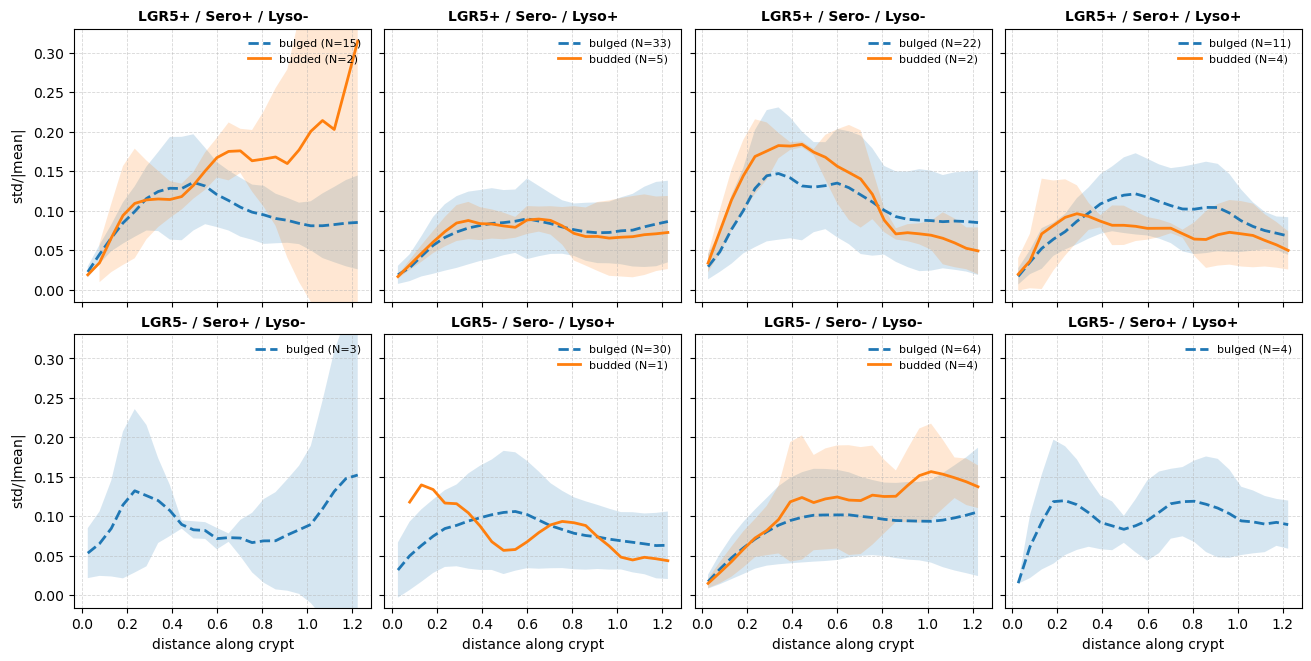

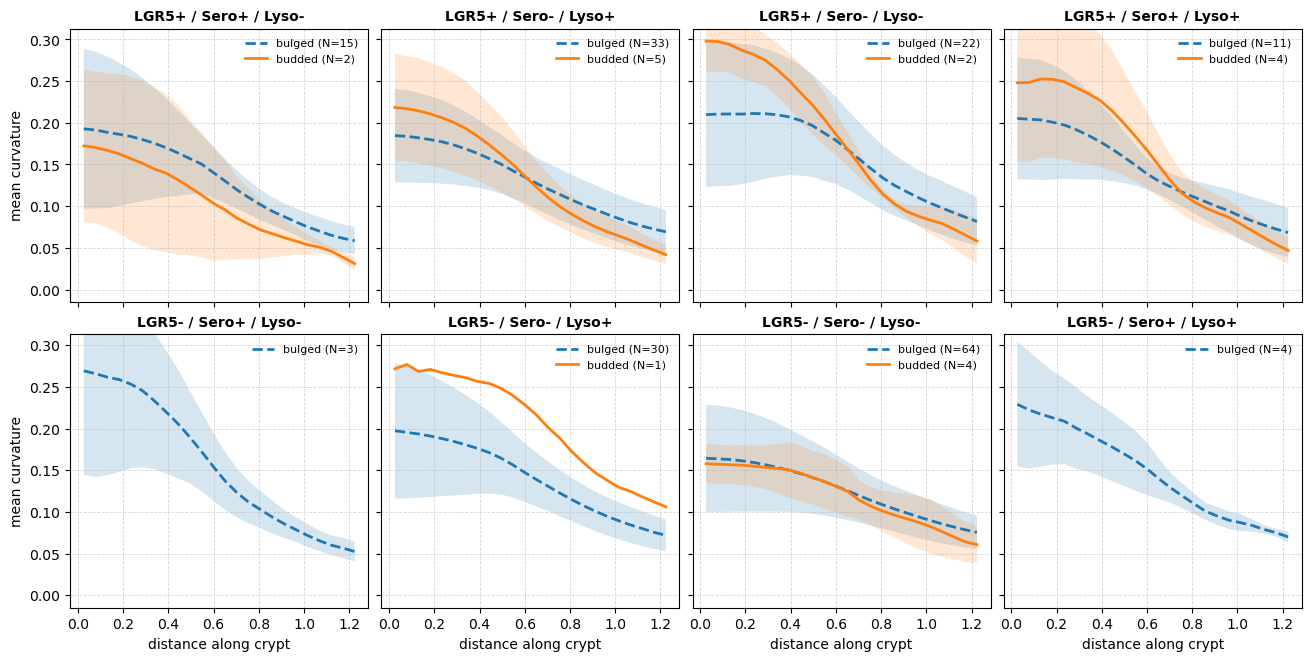

In [182]:
df_sel = inspection_df.copy()
# examples:
# df_sel = inspection_df.query("timepoint == 'day4'")
# df_sel = inspection_df.query("is_budded == True")
# df_sel = inspection_df.query("coexpression_cat in [0, 3]")


bin_edges = np.linspace(0, 1.25, 25)

prof_df = collect_curvature_profiles_from_inspection_table(
    df_sel,
    bin_edges=bin_edges,
    curvature_key="curvature_gauss",   # change if your saved key has another name
    weights_getter=None,         # or lambda seg: seg["vertex_areas"] if stored
)

prof_df = add_curvature_cv_profile(
    prof_df,
    mean_col="mean_profile",
    std_col="std_profile",
    count_col="count_profile",
    out_col="cv_profile",
)

plot_cv_profiles_by_coexpression(
    prof_df,
    profile_col="cv_profile",
    # timepoint="day3p5",
)

plot_mean_curvature_profiles_by_coexpression(
    prof_df,
    mean_col="mean_profile",
    # timepoint="day3p5",
)